In [ ]:
# Import libraries
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# Display the first 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Display the first 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Number of rows and columns
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.sample(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
115,116,Female,19,65,50
40,41,Female,65,38,35
106,107,Female,66,63,50
154,155,Female,47,78,16
7,8,Female,23,18,94


In [ ]:
df["Genre"].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df["Genre"].value_counts()

,count
Genre,
Female,112
Male,88


In [ ]:
import seaborn as sns

# Display charts inside the notebook
%matplotlib inline

In [ ]:
sns.set_style("whitegrid")

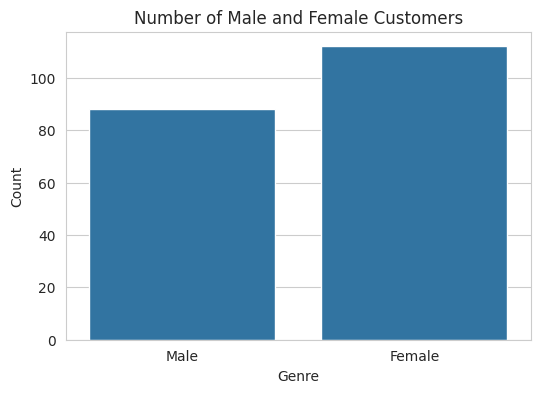

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Genre", data=df)

plt.title("Number of Male and Female Customers")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

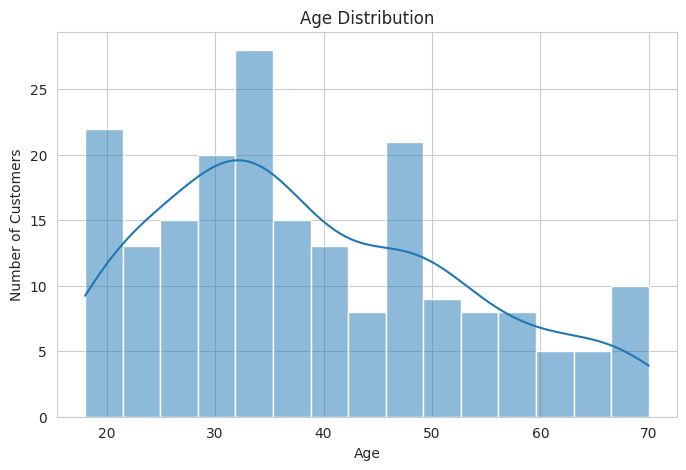

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

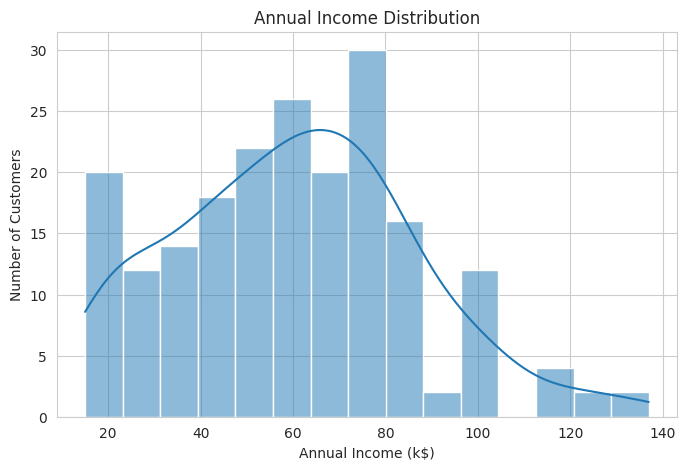

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

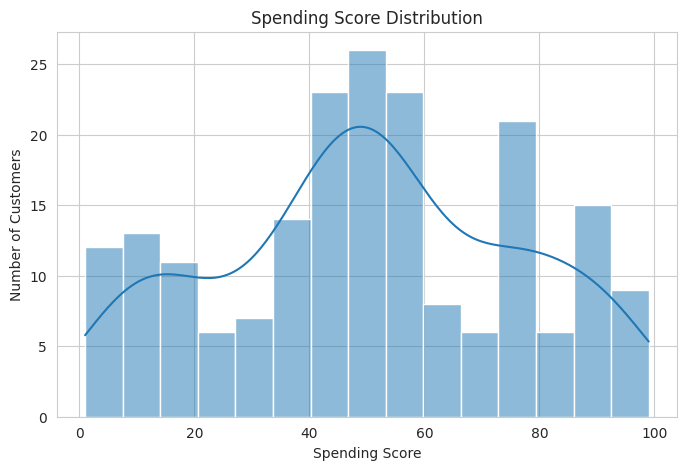

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=15, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

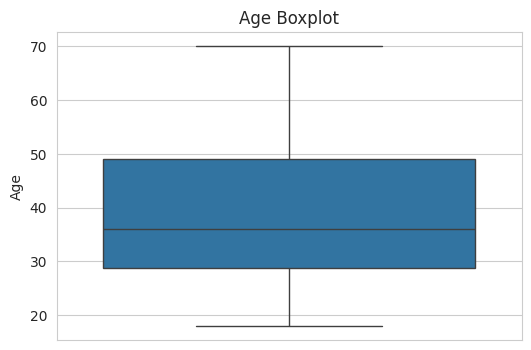

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Age"])

plt.title("Age Boxplot")

plt.show()

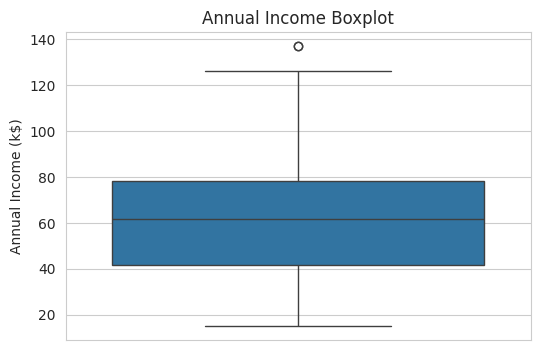

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Annual Income (k$)"])

plt.title("Annual Income Boxplot")

plt.show()

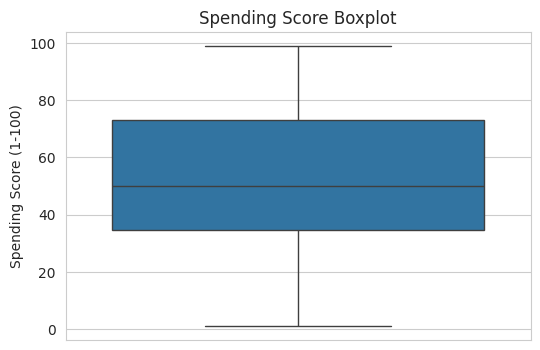

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Spending Score (1-100)"])

plt.title("Spending Score Boxplot")

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

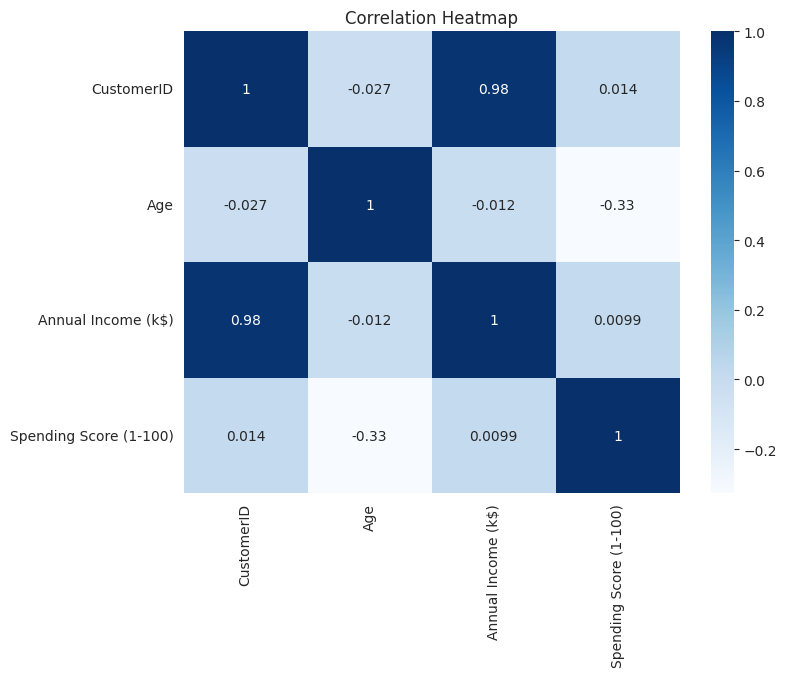

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

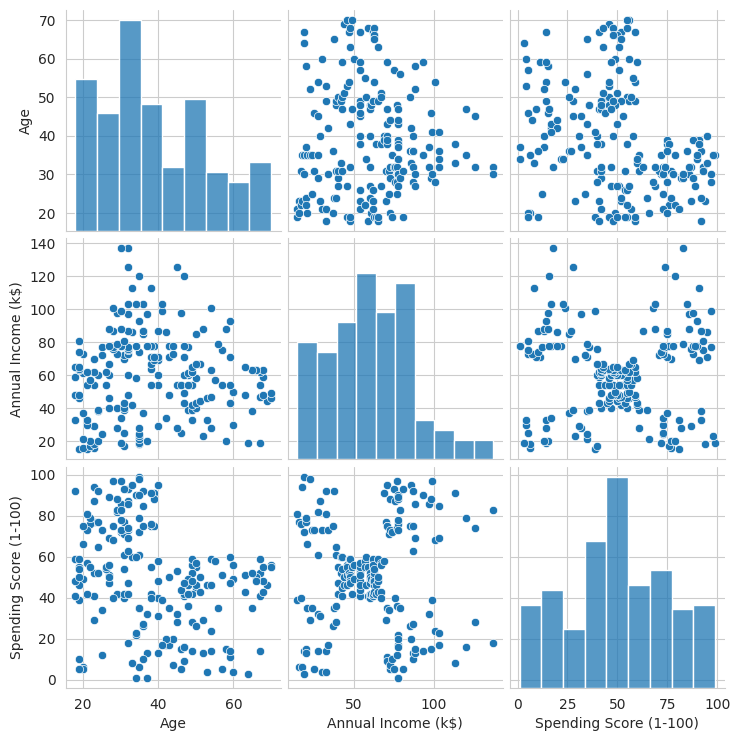

In [ ]:
sns.pairplot(
    df[
        [
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ]
)

plt.show()

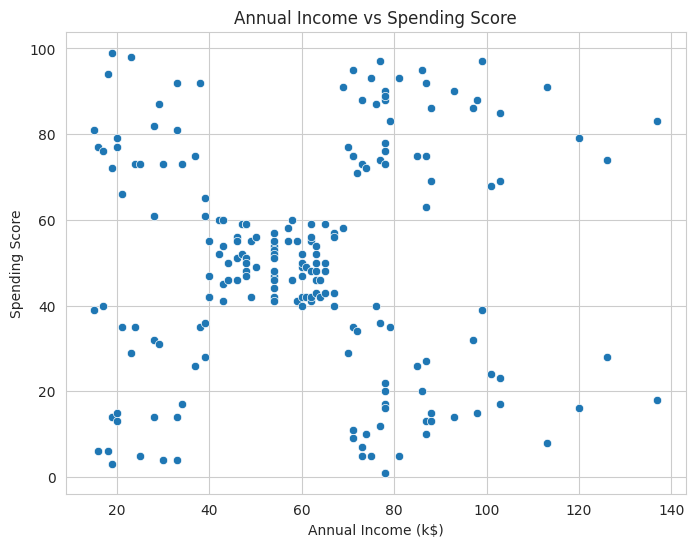

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [ ]:
# Select the features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Display the first 5 rows
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [ ]:
X_scaled.shape

(200, 3)

In [ ]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [ ]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

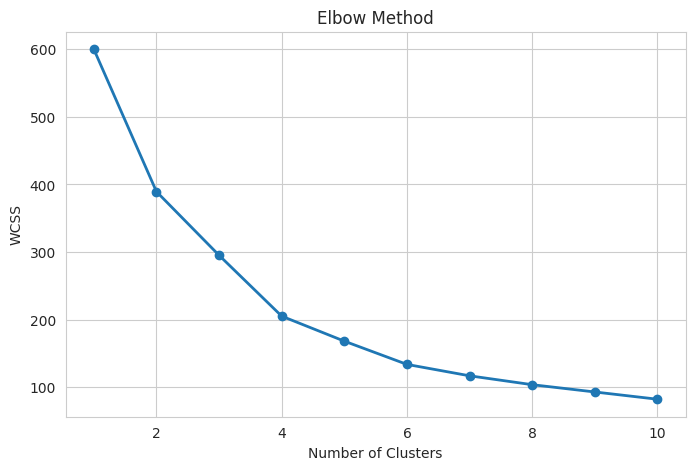

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [ ]:
n_clusters = 5

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
df["Cluster"] = kmeans.labels_

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [ ]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,20
1,54
2,40
3,39
4,47


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.417


In [ ]:
kmeans.cluster_centers_

array([[ 0.5310735 , -1.2905084 , -1.23646671],
       [-0.98067852, -0.74305983,  0.46744035],
       [-0.42880597,  0.97484722,  1.21608539],
       [ 0.07333084,  0.97494509, -1.19729675],
       [ 1.20484056, -0.23577338, -0.05236781]])

In [ ]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,24.100000,46.250000,26.750000,18.350000
1,55.648148,25.185185,41.092593,62.240741
2,161.025000,32.875000,86.100000,81.525000
3,159.743590,39.871795,86.102564,19.358974
4,83.872340,55.638298,54.382979,48.851064


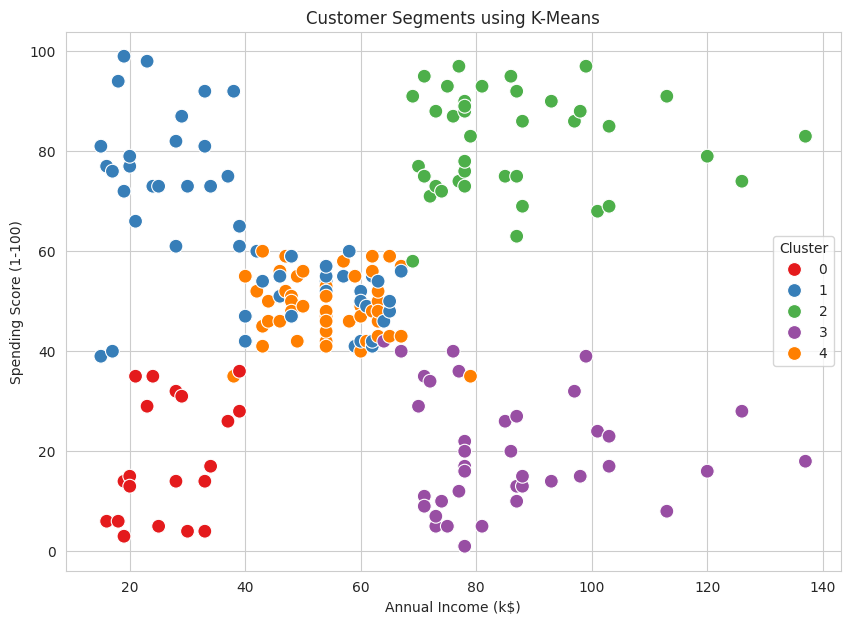

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.show()

In [ ]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Age','Annual Income (k$)','Spending Score (1-100)']
)

centers_df

,Age,Annual Income (k$),Spending Score (1-100)
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


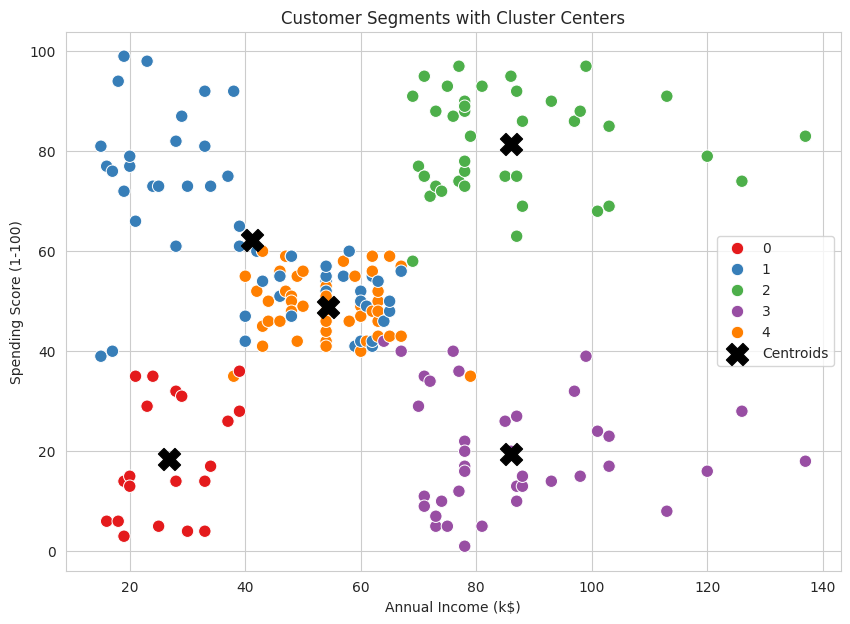

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.scatter(
    centers_df['Annual Income (k$)'],
    centers_df['Spending Score (1-100)'],
    color='black',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("Customer Segments with Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster").agg({
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean",
    "CustomerID":"count"
})

cluster_summary.rename(columns={"CustomerID":"Number of Customers"})

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,46.250000,26.750000,18.350000,20
1,25.185185,41.092593,62.240741,54
2,32.875000,86.100000,81.525000,40
3,39.871795,86.102564,19.358974,39
4,55.638298,54.382979,48.851064,47


In [ ]:
df.to_csv("Customer_Segmentation_Result.csv", index=False)

print("File exported successfully!")

File exported successfully!


In [ ]:
from google.colab import files

files.download("Customer_Segmentation_Result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>